In [27]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from collections import defaultdict

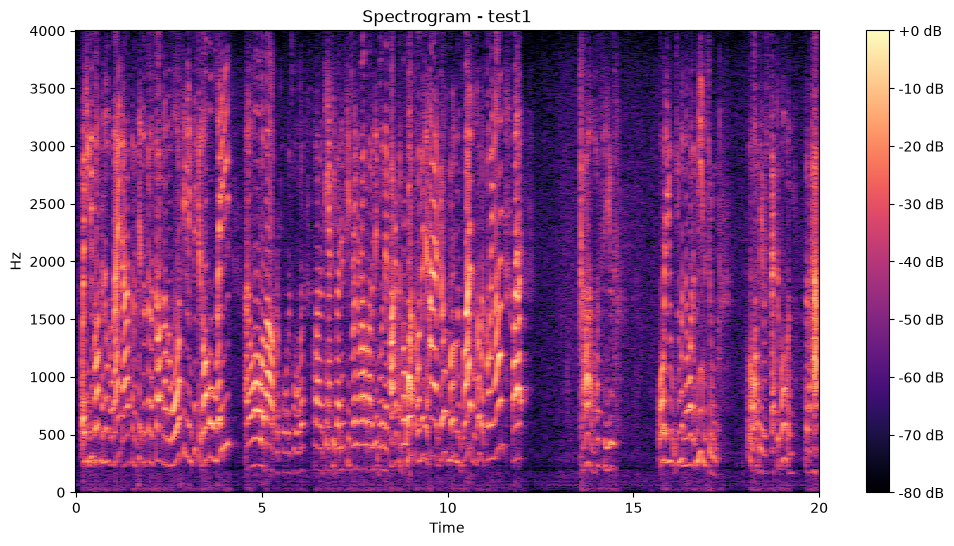

In [12]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

y, sr = librosa.load("../data/audio/test1.wav", sr=8000)
S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram - test1')
plt.show()

In [13]:
from scipy.ndimage import maximum_filter

def find_peaks(S_db, neighborhood_size=20, threshold=-40):
    # Local max filter: each point compared to its neighborhood
    local_max = maximum_filter(S_db, size=neighborhood_size) == S_db
    # Only keep peaks above a minimum loudness (ignore silence/noise floor)
    peaks_mask = local_max & (S_db > threshold)
    
    freq_idx, time_idx = np.where(peaks_mask)
    return list(zip(time_idx, freq_idx))  # constellation points

In [14]:
peaks = find_peaks(S_db, neighborhood_size=20, threshold=-40)
print("Number of peaks found:", len(peaks))

Number of peaks found: 477


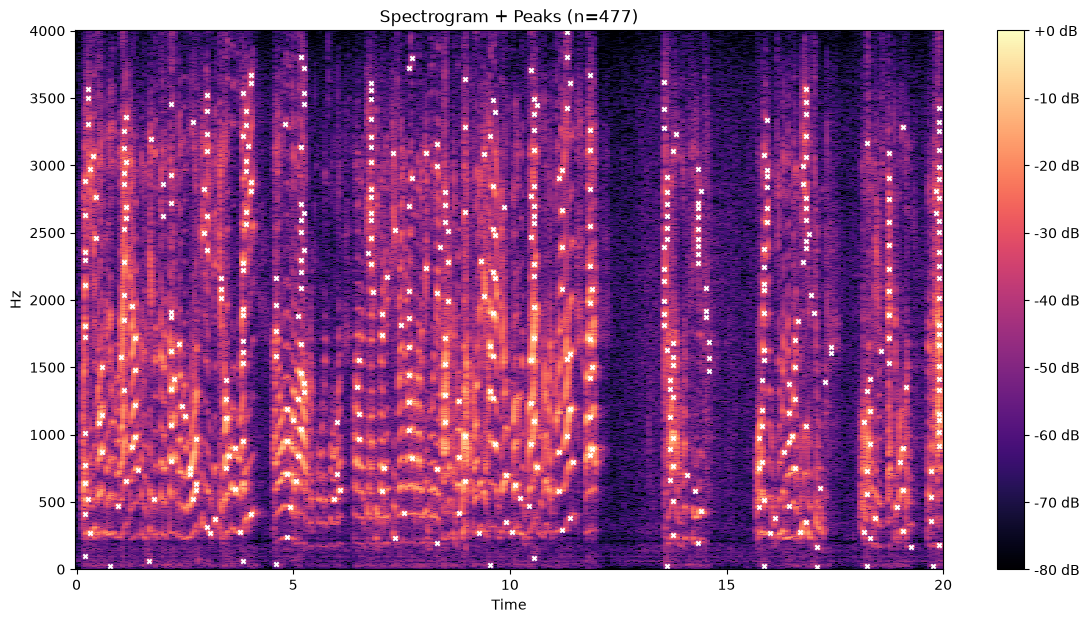

In [15]:
plt.figure(figsize=(14, 7))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', hop_length=512)
plt.colorbar(format='%+2.0f dB')

# overlay peaks
times = librosa.frames_to_time([p[0] for p in peaks], sr=sr, hop_length=512)
freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)[[p[1] for p in peaks]]
plt.scatter(times, freqs, color='white', s=10, marker='x')

plt.title(f'Spectrogram + Peaks (n={len(peaks)})')
plt.show()

In [16]:
thresholds = [-30, -40, -50, -60]
neighborhood_size = 20

for t in thresholds:
    peaks = find_peaks(S_db, neighborhood_size=neighborhood_size, threshold=t)
    print(f"threshold={t:4d} -> {len(peaks)} peaks  ({len(peaks)/20:.1f} peaks/sec)")

threshold= -30 -> 358 peaks  (17.9 peaks/sec)
threshold= -40 -> 477 peaks  (23.9 peaks/sec)
threshold= -50 -> 551 peaks  (27.6 peaks/sec)
threshold= -60 -> 558 peaks  (27.9 peaks/sec)


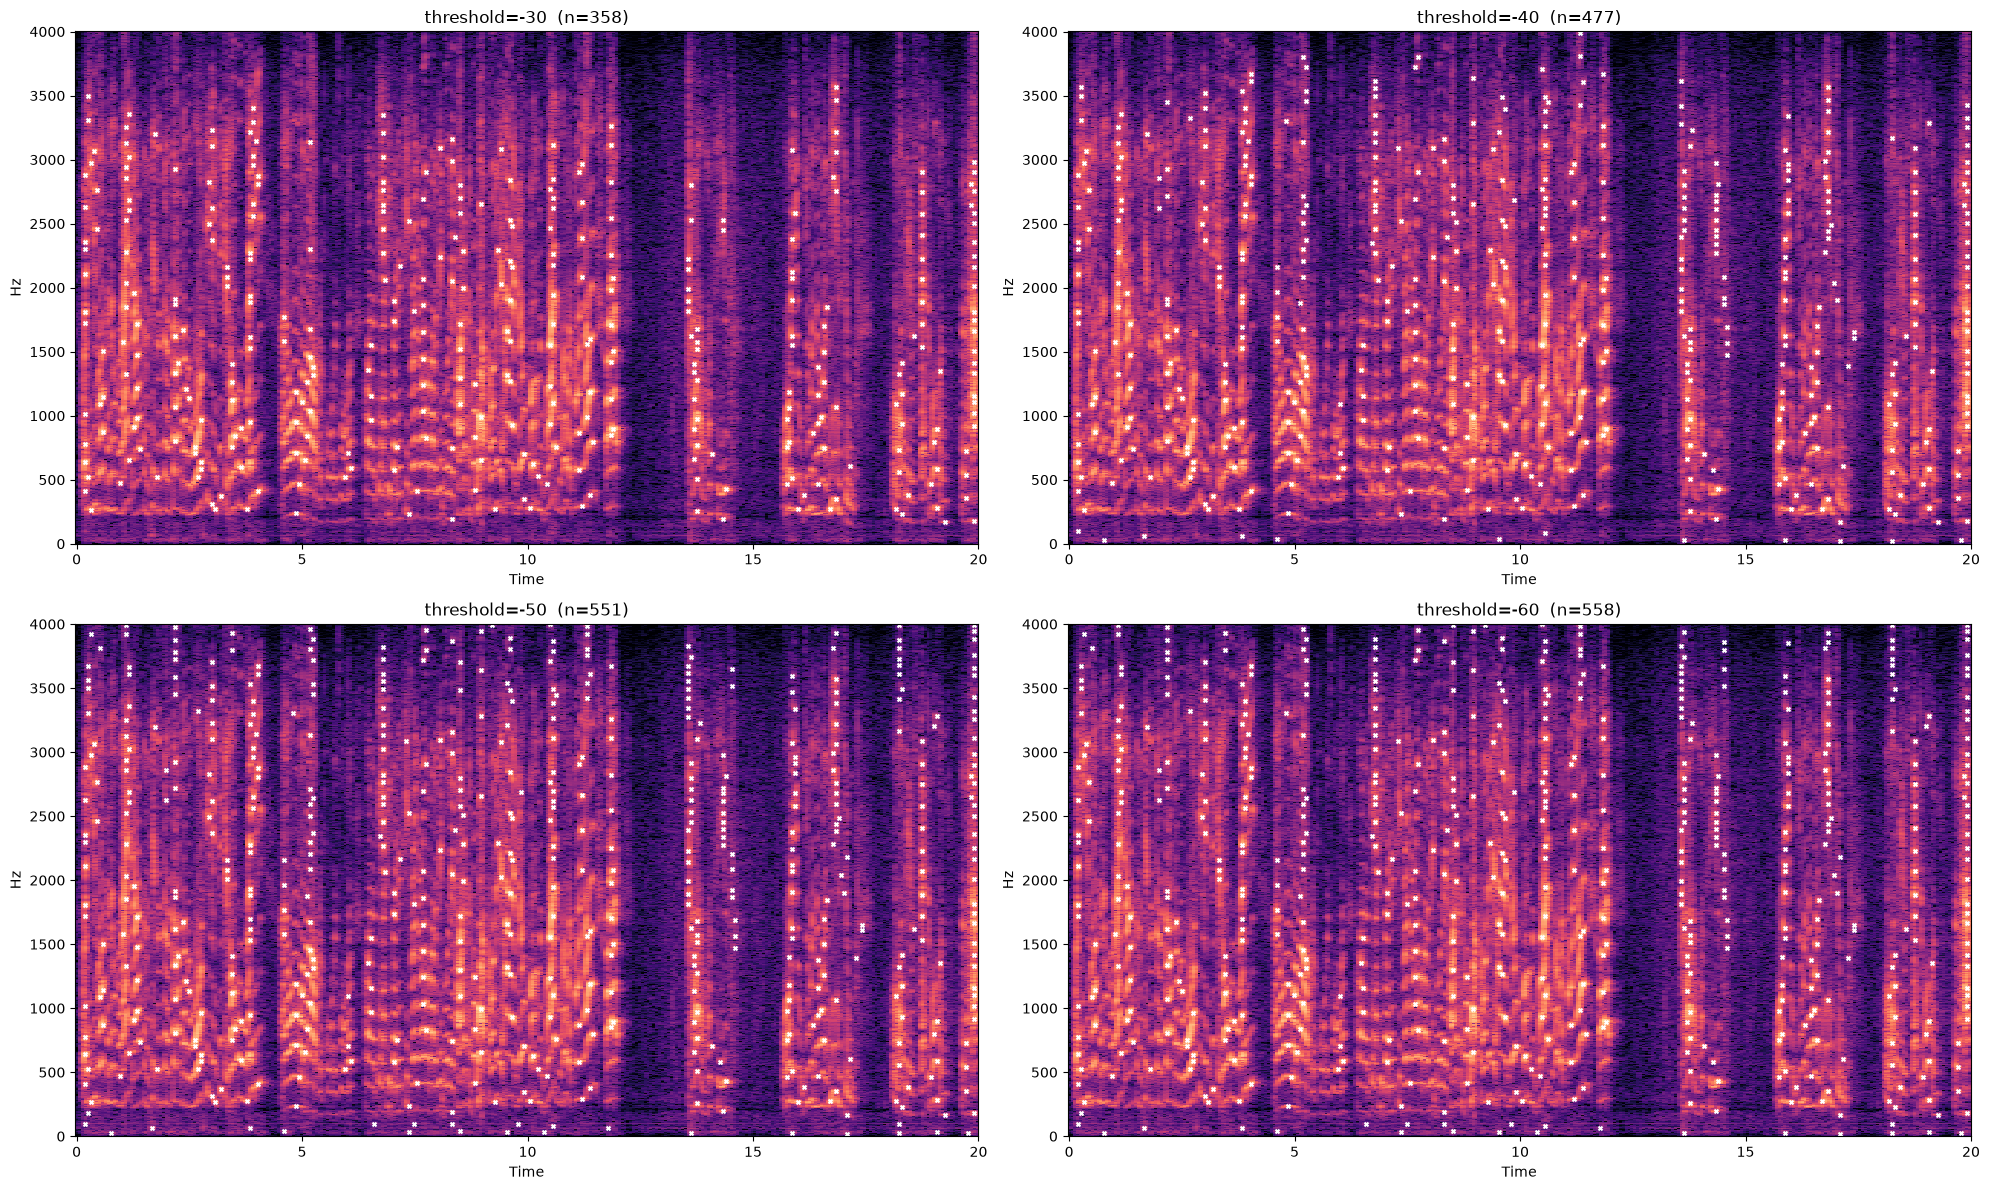

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
thresholds = [-30, -40, -50, -60]

for ax, t in zip(axes.flat, thresholds):
    peaks = find_peaks(S_db, neighborhood_size=20, threshold=t)
    
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', 
                                     hop_length=512, ax=ax)
    times = librosa.frames_to_time([p[0] for p in peaks], sr=sr, hop_length=512)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)[[p[1] for p in peaks]]
    ax.scatter(times, freqs, color='white', s=8, marker='x')
    ax.set_title(f'threshold={t}  (n={len(peaks)})')

plt.tight_layout()
plt.show()

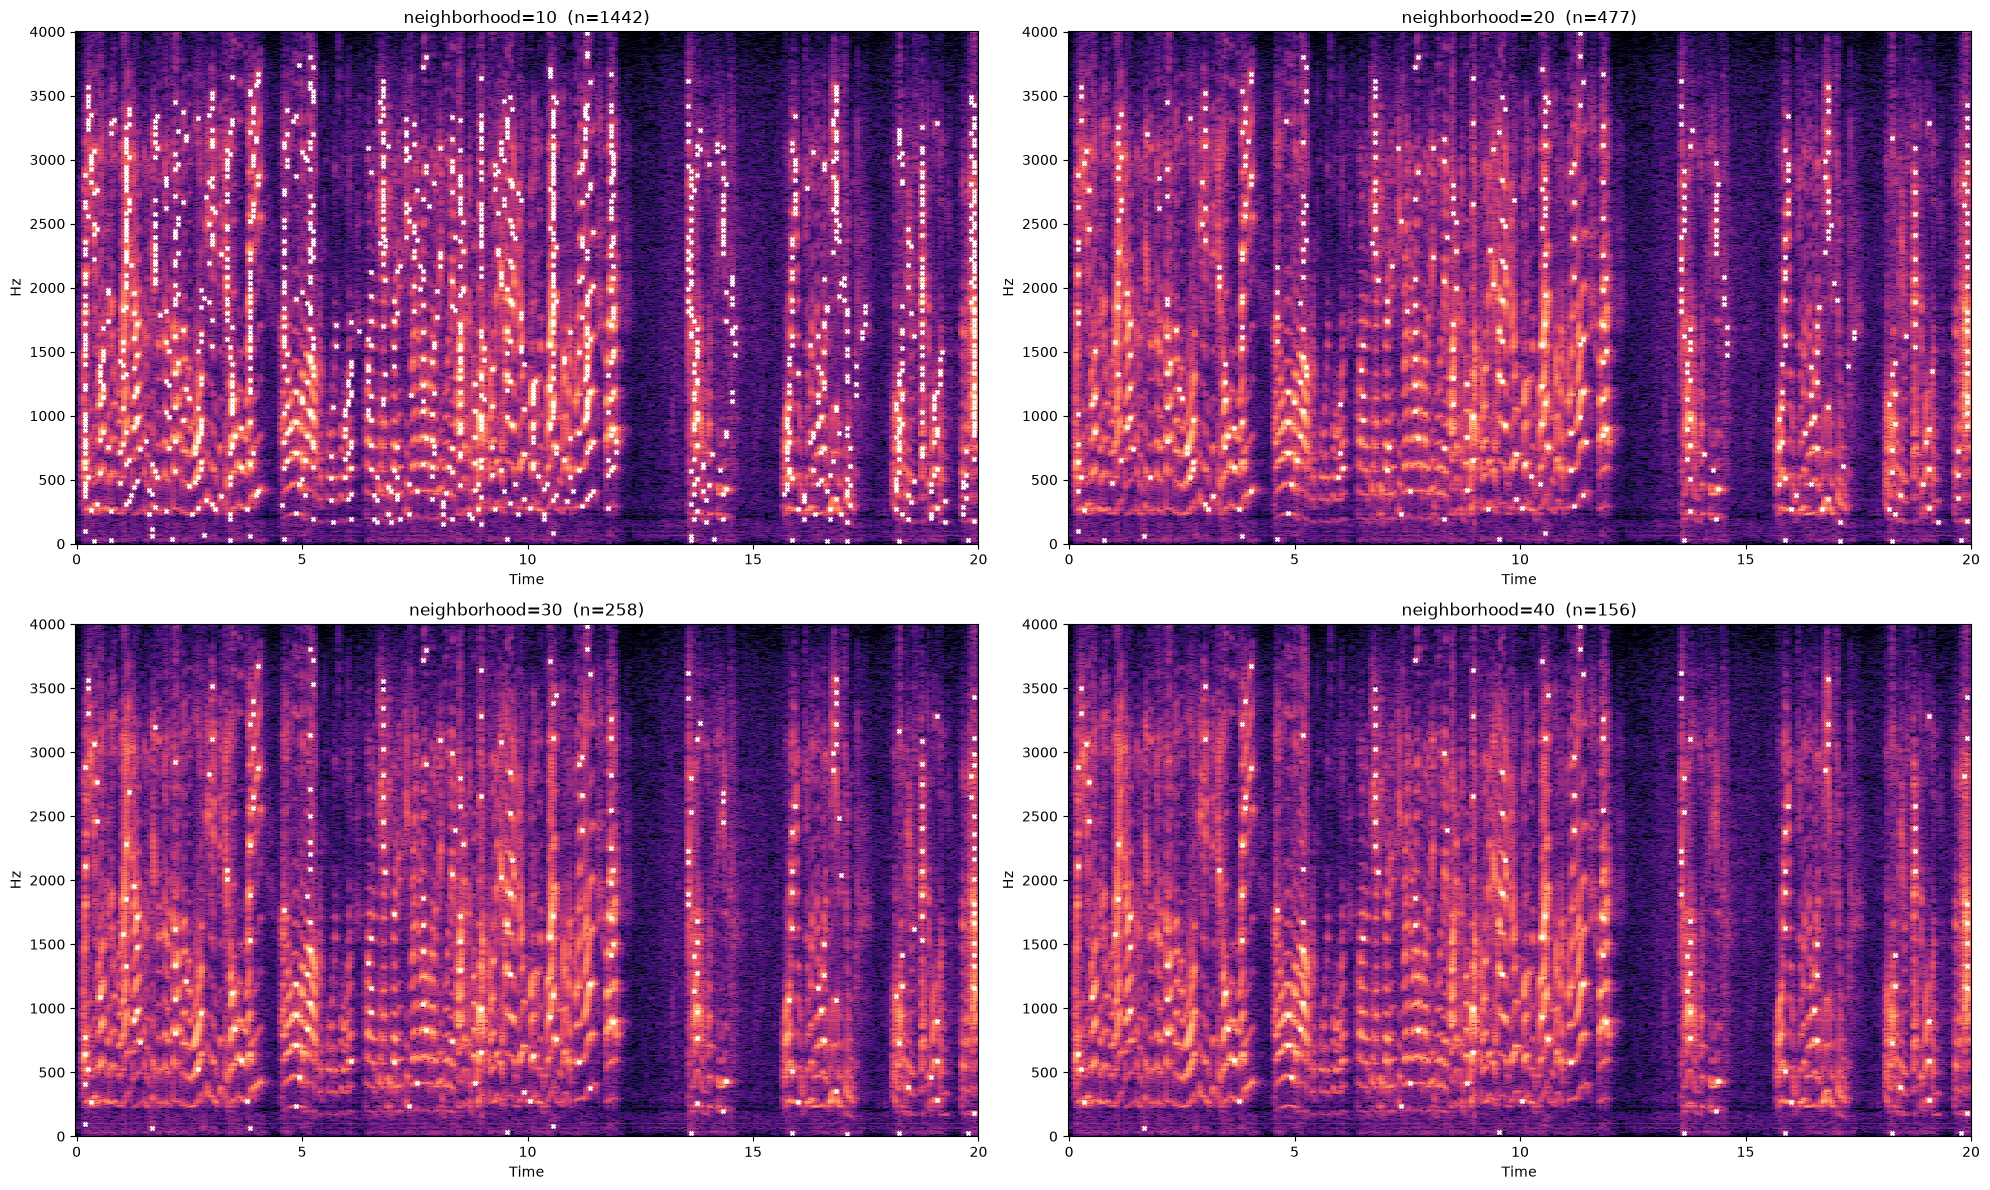

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
sizes = [10, 20, 30, 40]
best_threshold = -40  # update based on step 2 findings

for ax, n in zip(axes.flat, sizes):
    peaks = find_peaks(S_db, neighborhood_size=n, threshold=best_threshold)
    
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', 
                               hop_length=512, ax=ax)
    times = librosa.frames_to_time([p[0] for p in peaks], sr=sr, hop_length=512)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)[[p[1] for p in peaks]]
    ax.scatter(times, freqs, color='white', s=8, marker='x')
    ax.set_title(f'neighborhood={n}  (n={len(peaks)})')

plt.tight_layout()
plt.show()

In [19]:
peaks = find_peaks(S_db, neighborhood_size=20, threshold=-50)
peaks.sort(key=lambda p: p[0])  # sort by time_idx — required for target zone lookahead
print(f"Total peaks: {len(peaks)}")

Total peaks: 551


In [20]:
def hash_pack(f1, f2, dt):
    # pack into a 32-bit int: 10 bits f1, 10 bits f2, 12 bits dt
    f1 = f1 & 0x3FF   # clamp to 10 bits (0-1023)
    f2 = f2 & 0x3FF
    dt = dt & 0xFFF   # clamp to 12 bits (0-4095)
    return (f1 << 22) | (f2 << 12) | dt

In [21]:
def generate_hashes(peaks, fan_out=10, min_dt=1, max_dt=100, max_freq_dist=200):
    """
    peaks: list of (time_idx, freq_idx), sorted by time_idx
    fan_out: max number of target points paired per anchor
    min_dt/max_dt: time window (in frames) defining the target zone ahead of anchor
    max_freq_dist: max frequency distance (in bins) allowed for pairing
    """
    hashes = []
    n = len(peaks)
    
    for i in range(n):
        t1, f1 = peaks[i]
        count = 0
        
        for j in range(i + 1, n):
            t2, f2 = peaks[j]
            dt = t2 - t1
            
            if dt < min_dt:
                continue
            if dt > max_dt:
                break  # since sorted by time, no point continuing
            if abs(f2 - f1) > max_freq_dist:
                continue
            
            h = hash_pack(f1, f2, dt)
            hashes.append((h, t1))  # (hash, anchor_time_offset)
            
            count += 1
            if count >= fan_out:
                break
    
    return hashes

In [22]:
hashes = generate_hashes(peaks, fan_out=10, min_dt=1, max_dt=100, max_freq_dist=200)

print(f"Total hashes generated: {len(hashes)}")
print(f"Ratio (hashes/peak): {len(hashes)/len(peaks):.1f}")
print("\nFirst 10 hashes (hash_value, anchor_time_offset):")
for h, t in hashes[:10]:
    print(h, t)

Total hashes generated: 5181
Ratio (hashes/peak): 9.4

First 10 hashes (hash_value, anchor_time_offset):
105046017 3
105406465 3
105136130 3
105771014 3
104886281 3
105353228 3
105541647 3
105631763 3
104923159 3
105406489 3


In [23]:
def hash_unpack(h):
    dt = h & 0xFFF
    f2 = (h >> 12) & 0x3FF
    f1 = (h >> 22) & 0x3FF
    return f1, f2, dt

# verify round-trip on real data
for h, t in hashes[:5]:
    f1, f2, dt = hash_unpack(h)
    print(f"hash={h:>10}  anchor_t={t:>4}  ->  f1={f1:>4} f2={f2:>4} dt={dt:>4}")

hash= 105046017  anchor_t=   3  ->  f1=  25 f2=  46 dt=   1
hash= 105406465  anchor_t=   3  ->  f1=  25 f2= 134 dt=   1
hash= 105136130  anchor_t=   3  ->  f1=  25 f2=  68 dt=   2
hash= 105771014  anchor_t=   3  ->  f1=  25 f2= 223 dt=   6
hash= 104886281  anchor_t=   3  ->  f1=  25 f2=   7 dt=   9


In [24]:
print("Middle hashes:")
for h, t in hashes[len(hashes)//2 : len(hashes)//2 + 5]:
    print(h, t)

print("Last hashes:")
for h, t in hashes[-5:]:
    print(h, t)

Middle hashes:
1419005953 149
1419333633 149
1419669505 149
1418649602 149
1418412038 149
Last hashes:
3022790657 310
3022942209 310
3023028225 310
3023163393 310
3023314945 310


In [25]:
def fingerprint(wav_path, n_fft=2048, hop_length=512, neighborhood_size=20, 
                 threshold=-50, fan_out=10, min_dt=1, max_dt=100, max_freq_dist=200):
    y, sr = librosa.load(wav_path, sr=8000)
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    
    peaks = find_peaks(S_db, neighborhood_size=neighborhood_size, threshold=threshold)
    peaks.sort(key=lambda p: p[0])
    
    hashes = generate_hashes(peaks, fan_out=fan_out, min_dt=min_dt, 
                               max_dt=max_dt, max_freq_dist=max_freq_dist)
    return hashes

In [39]:
from collections import defaultdict

def build_index(track_hashes_dict):
    """
    track_hashes_dict: { movie_id: [(hash, offset_time), ...], ... }
    returns: { hash: [(movie_id, offset_time), ...], ... }
    """
    index = defaultdict(list)
    for movie_id, hashes in track_hashes_dict.items():
        for h, t in hashes:
            index[h].append((movie_id, t))
    return index

# fingerprint your "database" (the full test1.wav)
db_hashes = fingerprint("../data/audio/query1_quiet.wav")
index = build_index({"test1": db_hashes})
print(f"Index has {len(index)} unique hashes")

Index has 1091 unique hashes


In [40]:
query_hashes = fingerprint("../data/audio/query1_quiet.wav")
print(f"Query has {len(query_hashes)} hashes")

# for each query hash, look up matches in the index
matches = []  # (movie_id, db_time, query_time)
for h, query_t in query_hashes:
    if h in index:
        for movie_id, db_t in index[h]:
            matches.append((movie_id, db_t, query_t))

print(f"Total hash matches found: {len(matches)}")

Query has 1091 hashes
Total hash matches found: 1091


In [41]:
from collections import Counter

# offset = where in the database this query timestamp corresponds to
offsets = [db_t - query_t for (movie_id, db_t, query_t) in matches]

offset_counts = Counter(offsets)
most_common = offset_counts.most_common(10)

print("Top 10 most common offsets (offset: count):")
for offset, count in most_common:
    print(f"{offset:>6} : {count}")


Top 10 most common offsets (offset: count):
     0 : 1091


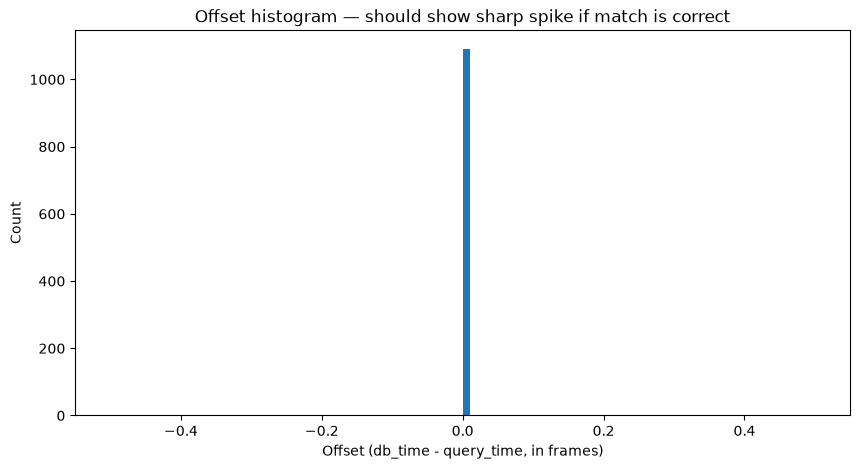

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(offsets, bins=100)
plt.xlabel("Offset (db_time - query_time, in frames)")
plt.ylabel("Count")
plt.title("Offset histogram — should show sharp spike if match is correct")
plt.show()

In [43]:
print("Index built from:", list(track_hashes_dict.keys()) if 'track_hashes_dict' in dir() else "check your build_index call")

Index built from: check your build_index call


In [46]:
# what's the index built from?
db_hashes = fingerprint("../data/audio/test1.wav")
index = build_index({"test1": db_hashes})
print("DB (test1.wav) hash count:", len(db_hashes))

# what's the query?
query_hashes = fingerprint("../data/audio/query1.wav")
print("Query (query1.wav) hash count:", len(query_hashes))

query_hashes = fingerprint("../data/audio/query1_quiet.wav")
print("Query (query1_quiet.wav) hash count:", len(query_hashes))

DB (test1.wav) hash count: 5181
Query (query1.wav) hash count: 1091
Query (query1_quiet.wav) hash count: 1091


In [47]:
query_hashes_noisy = fingerprint("../data/audio/query1_noisy.wav")
print(f"Noisy query hashes: {len(query_hashes_noisy)}")

matches_noisy = []
for h, query_t in query_hashes_noisy:
    if h in index:
        for movie_id, db_t in index[h]:
            matches_noisy.append((movie_id, db_t, query_t))

print(f"Matches found: {len(matches_noisy)}")

offsets_noisy = [db_t - query_t for (_, db_t, query_t) in matches_noisy]
print(Counter(offsets_noisy).most_common(10))

Noisy query hashes: 1289
Matches found: 528
[(np.int64(125), 526), (np.int64(206), 1), (np.int64(9), 1)]


In [3]:
def generate_hashes(peaks, fan_out=10, target_time_range=(0, 50), target_freq_range=100):
    # sort by time so target zone lookahead works
    peaks.sort(key=lambda p: p[0])
    hashes = []
    
    for i, (t1, f1) in enumerate(peaks):
        # look ahead within target zone
        count = 0
        for t2, f2 in peaks[i+1:]:
            dt = t2 - t1
            if dt < target_time_range[0]:
                continue
            if dt > target_time_range[1]:
                break  # peaks sorted by time, no point in continuing
            if abs(f2 - f1) > target_freq_range:
                continue
            
            # pack into a hash: (f1, f2, dt) -> single integer
            h = hash_pack(f1, f2, dt)
            hashes.append((h, t1))  # (hash, anchor_time_offset)
            
            count += 1
            if count >= fan_out:
                break
    return hashes

def hash_pack(f1, f2, dt):
    # pack into 32-bit int: e.g. 10 bits f1, 10 bits f2, 12 bits dt
    return (f1 & 0x3FF) << 22 | (f2 & 0x3FF) << 12 | (dt & 0xFFF)

In [4]:
def fingerprint(wav_path):
    y, sr = librosa.load(wav_path, sr=8000)
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    
    peaks = find_peaks(S_db)
    hashes = generate_hashes(peaks)
    return hashes